<a href="https://colab.research.google.com/github/ummetaahiaadev/Fire_No-fire-223007212/blob/main/223007212_F_or_No_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!ls /content/


archive.zip  sample_data


Archive:  archive.zip
  inflating: /content/dataset/fire_dataset/fire_images/fire.1.png  
  inflating: /content/dataset/fire_dataset/fire_images/fire.10.png  
  inflating: /content/dataset/fire_dataset/fire_images/fire.100.png  
  inflating: /content/dataset/fire_dataset/fire_images/fire.101.png  
  inflating: /content/dataset/fire_dataset/fire_images/fire.102.png  
  inflating: /content/dataset/fire_dataset/fire_images/fire.103.png  
  inflating: /content/dataset/fire_dataset/fire_images/fire.104.png  
  inflating: /content/dataset/fire_dataset/fire_images/fire.105.png  
  inflating: /content/dataset/fire_dataset/fire_images/fire.106.png  
  inflating: /content/dataset/fire_dataset/fire_images/fire.107.png  
  inflating: /content/dataset/fire_dataset/fire_images/fire.108.png  
  inflating: /content/dataset/fire_dataset/fire_images/fire.109.png  
  inflating: /content/dataset/fire_dataset/fire_images/fire.11.png  
  inflating: /content/dataset/fire_dataset/fire_images/fire.110.png  
  

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9444 - loss: 0.1020 - val_accuracy: 1.0000 - val_loss: 9.0339e-20
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 978ms/step - accuracy: 1.0000 - loss: 1.7610e-21 - val_accuracy: 1.0000 - val_loss: 4.1841e-22
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 38s 880ms/step - accuracy: 1.0000 - loss: 1.2719e-22 - val_accuracy: 1.0000 - val_loss: 2.4844e-22
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 905ms/step - accuracy: 1.0000 - loss: 3.7249e-23 - val_accuracy: 1.0000 - val_loss: 2.3747e-22
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 856ms/step - accuracy: 1.0000 - loss: 1.1018e-21 - val_accuracy: 1.0000 - val_loss: 2.3659e-22
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 879ms/step - accuracy: 1.0000 - loss: 1.0538e-22 - val_accuracy: 1.0000 - val_loss: 2.3654e-22
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 922ms/step - accuracy: 1.0000 - loss: 1.0586e-21 - val_accuracy: 1.0000 - val_loss: 2.3654e-22
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 904ms/

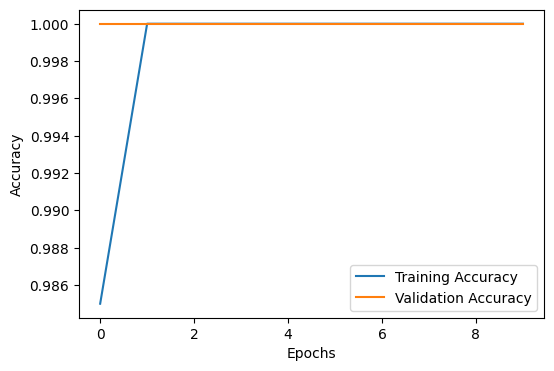

✅ Model saved successfully!


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10

!unzip -o archive.zip -d /content/dataset

DATA_DIR = "/content/dataset"

print("Dataset folders:", os.listdir(DATA_DIR))

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_data = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=True
)

print("Class indices:", train_data.class_indices)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

model.save("fire_no_fire_model.h5")
print("✅ Model saved successfully!")
